<a href="https://colab.research.google.com/github/emanhassan2020/HandsOn/blob/main/Agents/HuggingFace/agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agent

In this notebook, **we're going to build a simple agent using using LangGraph**.

This notebook is part of the <a href="https://www.hf.co/learn/agents-course">Hugging Face Agents Course</a>, a free course from beginner to expert, where you learn to build Agents.

![Agents course share](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/communication/share.png)

As seen in the Unit 1, an agent needs 3 steps as introduced in the ReAct architecture :
[ReAct](https://react-lm.github.io/), a general agent architecture.

* `act` - let the model call specific tools
* `observe` - pass the tool output back to the model
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


![Agent](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit2/LangGraph/Agent.png)

In [1]:
#pip install -q -U langchain_openai langchain_core langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 36.5 MB/s eta 0:00:00


In [1]:
!pip install -q transformers bitsandbytes accelerate
!pip install -q langgraph langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.5 MB/s eta 0:00:00


In [1]:
import torch
from typing import Dict, Any, TypedDict
from PIL import Image
from langgraph.graph import StateGraph, START, END
from transformers import pipeline
from google.colab import userdata

# Load PaliGemma pipeline (using mix-224 checkpoint optimized for Colab VRAM)
hf_token = userdata.get('HF_TOKEN')
model_id = "google/paligemma2-3b-mix-224"

# If you fine-tuned adapters using LoRA, swap model_id out for your local directory path
vision_llm = pipeline(
    task="image-text-to-text",
    model=model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

In [3]:
!pip install langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [2]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
#from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

from google.colab import userdata

# Replace 'YOUR_SECRET_NAME' with the actual name of your secret
#OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
#os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# Initialize our LLM
#model = ChatOpenAI(model="gpt-4o", temperature=0)
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)
#model = ChatOpenAI(model="google/flan-t5-xxl", temperature=0)

In [11]:
import base64
from langchain_core.messages import HumanMessage
#from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI


#vision_llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)
#vision_llm = ChatOpenAI(model="gpt-4o")


def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
    """
    all_text = ""
    try:

        # Read image and encode as base66
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # You can choose whether to raise or just return an empty string / error message
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""


#llm = ChatOpenAI(model="gpt-4o")


def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b


tools = [
    divide,
    extract_text
]
llm_with_tools = llm.bind_tools(tools)

Let's create our LLM and prompt it with the overall desired agent behavior.

In [12]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The input document
    input_file: Optional[str]  # Contains file path, type (PNG)
    messages: Annotated[list[AnyMessage], add_messages]

In [13]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.utils.function_calling import convert_to_openai_tool


def assistant(state: AgentState):
    # System message
    textual_description_of_tool = """
extract_text(img_path: str) -> str:
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
divide(a: int, b: int) -> float:
    Divide a and b
"""
    image = state["input_file"]
    sys_msg = SystemMessage(content=f"You are an helpful agent that can analyse some images and run some computatio without provided tools :\n{textual_description_of_tool} \n You have access to some otpional images. Currently the loaded images is : {image}")

    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])], "input_file": state["input_file"]}

We define a `tools` node with our list of tools.

The `assistant` node is just our model with bound tools.

We create a graph with `assistant` and `tools` nodes.

We add `tools_condition` edge, which routes to `End` or to `tools` based on  whether the `assistant` calls a tool.

Now, we add one new step:

We connect the `tools` node *back* to the `assistant`, forming a loop.

* After the `assistant` node executes, `tools_condition` checks if the model's output is a tool call.
* If it is a tool call, the flow is directed to the `tools` node.
* The `tools` node connects back to `assistant`.
* This loop continues as long as the model decides to call tools.
* If the model response is not a tool call, the flow is directed to END, terminating the process.

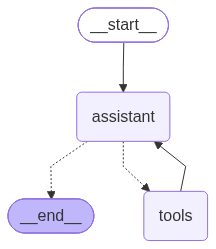

In [14]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [15]:
messages = [HumanMessage(content="Divide 6790 by 5")]

messages = react_graph.invoke({"messages": messages, "input_file": "/content/images.png"})

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [16]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide 6790 by 5
================================== Ai Message ==================================

[]
Tool Calls:
  divide (call_258501)
 Call ID: call_258501
  Args:
    b: 5
    a: 6790
================================= Tool Message =================================
Name: divide

1358.0
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Dividing 6790 by 5 gives **1358**.', 'extras': {'signature': 'EqIBCp8BARFNMg/N3sXqhSeNSkPryp4C+daav1d48OjWs42SJNga+3xSufR/C++j/STojMYMTjM7DggC6B46w3sKIoRMVlYFhg9kXtqRoBGe1Wh2yUckDqKj+7Vf+ly/DplVxewV2lkwwqmRefFlOuxSZRvRvkC7srLeuDsrw1lkOYzjUrRr/Pihcv+n2D4C1U8vE+iYSBSLvz850marqlcQoUvm'}}]


## Training program
MR Wayne left a note with his training program for the week. I came up with a recipe for dinner left in a note.

you can find the document [HERE](https://huggingface.co/datasets/agents-course/course-images/blob/main/en/unit2/LangGraph/Batman_training_and_meals.png), so download it and upload it in the local folder.

![Training](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit2/LangGraph/Batman_training_and_meals.png)

In [ ]:
messages = [HumanMessage(content="According the note provided by MR wayne in the provided images. What's the list of items I should buy for the dinner menu ?")]

messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

In [ ]:
for m in messages['messages']:
    m.pretty_print()